 Arabic Dialect Detection using Classical Machine Learning

## Task Overview
This notebook builds a **Classical Machine Learning pipeline** for detecting Arabic dialects from speech audio.

### Selected Dialects
We will classify between 5 Arabic dialects (MADIS5 dataset):

1. Egyptian Arabic
2. Gulf Arabic
3. Levantine Arabic
4. Maghrebi Arabic
5. Modern Standard Arabic

### Dataset
Dataset used:

`MADIS5 - Spoken Arabic Dialects` (HuggingFace: `badrex/MADIS5-spoken-arabic-dialects`)

Dataset structure: HuggingFace `datasets` library, columns: `audio`, `dialect`, `segment_id`, `domain`, `audio_duration`

---


In [ ]:
# Install HuggingFace datasets library
!pip install datasets --quiet

from datasets import load_dataset

# Load MADIS5 dataset from HuggingFace
ds = load_dataset("badrex/MADIS5-spoken-arabic-dialects")
print(ds)
print("\nDialect classes:", list(set(ds['test']['dialect'])))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/test-00000-of-00003.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

data/test-00001-of-00003.parquet:   0%|          | 0.00/441M [00:00<?, ?B/s]

data/test-00002-of-00003.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4854 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['segment_id', 'audio', 'dialect', 'domain', 'audio_duration'],
        num_rows: 4854
    })
})

Dialect classes: ['Levantine Arabic', 'Maghrebi Arabic', 'Egyptian Arabic', 'Modern Standard Arabic', 'Gulf Arabic']


# 1. Install Required Libraries


In [ ]:
!pip install librosa soundfile scikit-learn matplotlib seaborn pandas numpy joblib datasets --quiet


# 2. Import Libraries


In [ ]:
import os
import io
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

import joblib


# 3. Dataset Paths


In [ ]:
# MADIS5 dialect labels (as they appear in the dataset)
DIALECTS = [
    "Egyptian Arabic",
    "Gulf Arabic",
    "Levantine Arabic",
    "Maghrebi Arabic",
]

print("Dialects to classify:", DIALECTS)


Dialects to classify: ['Egyptian Arabic', 'Gulf Arabic', 'Levantine Arabic', 'Maghrebi Arabic']


 4. Feature Extraction

We will use:

- MFCCs
- Chroma Features
- Spectral Contrast
- Zero Crossing Rate
- RMS Energy

These are classical audio-processing features widely used in speech and dialect classification.

---

## Why These Features?

### MFCCs
Capture pronunciation and vocal tract characteristics.

### Chroma
Capture tonal information.

### Spectral Contrast
Shows differences between peaks and valleys in speech frequencies.

### Zero Crossing Rate
Measures speech sharpness and speaking style.

### RMS Energy
Represents loudness and speaking dynamics.

---

# 5. Audio Feature Extraction Function


In [ ]:
def extract_features_from_signal(y, sr):
    """Extract features from a numpy audio array."""
    try:
        # Trim silence
        y, _ = librosa.effects.trim(y, top_db=20)

        if len(y) < 512:
            return None

        # 40 MFCCs + std
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfccs_mean = np.mean(mfccs.T, axis=0)
        mfccs_std  = np.std(mfccs.T, axis=0)

        # Delta MFCCs
        delta_mfccs = librosa.feature.delta(mfccs)
        delta_mean  = np.mean(delta_mfccs.T, axis=0)

        # Delta-Delta MFCCs
        delta2_mfccs = librosa.feature.delta(mfccs, order=2)
        delta2_mean  = np.mean(delta2_mfccs.T, axis=0)

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)

        # Spectral Contrast
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast.T, axis=0)

        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
        mel_mean = np.mean(librosa.power_to_db(mel).T, axis=0)

        # Spectral Rolloff
        rolloff_mean = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))

        # Zero Crossing Rate
        zcr_mean = np.mean(librosa.feature.zero_crossing_rate(y))

        # RMS Energy
        rms_mean = np.mean(librosa.feature.rms(y=y))

        features = np.hstack([
            mfccs_mean, mfccs_std, delta_mean, delta2_mean,
            chroma_mean, contrast_mean, mel_mean,
            [rolloff_mean, zcr_mean, rms_mean]
        ])
        return features

    except Exception as e:
        print(f"Error: {e}")
        return None

def extract_features(file_path):
    """Extract features from an audio file path."""
    try:
        y, sr = librosa.load(file_path, sr=22050)
        return extract_features_from_signal(y, sr)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


# 6. Load Dataset and Build Feature Matrix


In [ ]:
from datasets import load_dataset, Audio
import numpy as np
import librosa

# Load dataset
ds = load_dataset("badrex/MADIS5-spoken-arabic-dialects")

# Decode audio automatically
ds = ds.cast_column("audio", Audio(sampling_rate=22050))

data = ds['test']

X = []
y = []
failed = 0

for sample in data:
    dialect = sample['dialect']

    if dialect not in DIALECTS:
        continue

    try:
        # Load decoded audio
        audio = sample['audio']

        audio_array = np.array(audio['array'], dtype=np.float32)
        sr = audio['sampling_rate']

        # Feature extraction
        features = extract_features_from_signal(audio_array, sr)

        if features is not None:
            X.append(features)
            y.append(dialect)
        else:
            failed += 1

    except Exception as e:
        failed += 1
        print(f"Failed sample: {e}")
        continue

X = np.array(X)
y = np.array(y)

print(f"Feature Matrix Shape: {X.shape}")
print(f"Labels Shape: {y.shape}")
print(f"Failed samples: {failed}")

print("\nClass distribution:")
for d in DIALECTS:
    print(f"{d}: {np.sum(y == d)}")

Failed sample: No audio frames were decoded. This is probably because start_seconds is too high(0),or because stop_seconds(std::nullopt) is too low.
Feature Matrix Shape: (4127, 222)
Labels Shape: (4127,)
Failed samples: 1

Class distribution:
Egyptian Arabic: 1131
Gulf Arabic: 967
Levantine Arabic: 1153
Maghrebi Arabic: 876


# 7. Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 8. Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 9. Train Classical ML Model

## Support Vector Machine (SVM) — Improved

**Problem:** Iraqi audio was predicted as Lebanese, and Lebanese accuracy was low.

**Root Cause:** With only 13 MFCCs, Iraqi and Lebanese dialects share similar low-level features. The model confused them.

**Fixes Applied:**
1. **40 MFCCs + delta + delta-delta** — captures richer phonetic and temporal patterns that separate IRA from LEB
2. **Mel Spectrogram mean** — adds frequency-level dialect fingerprinting
3. **Silence trimming** — removes non-speech noise that misleads the model
4. **`class_weight='balanced'`** — ensures all 4 dialects are treated equally
5. **`C=1`** — lower regularization to avoid overfitting
6. **`CalibratedClassifierCV`** — gives reliable `predict_proba` scores

---


In [ ]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multiclass import OneVsRestClassifier

# Base SVM — balanced, less aggressive C to reduce LEB/IRA confusion
base_svm = SVC(
    kernel='rbf',
    C=2,              # reduced from 5 to prevent overfitting IRA→LEB
    gamma='scale',
    class_weight='balanced',
    probability=False  # handled by CalibratedClassifierCV below
)

# Calibrated wrapper gives better probability estimates
calibrated_svm = CalibratedClassifierCV(base_svm, cv=5)

# OneVsRest ensures each dialect gets its own dedicated boundary
model = OneVsRestClassifier(calibrated_svm)

model.fit(X_train, y_train)
print('Model trained successfully')
print(f'Feature vector size: {X_train.shape[1]} features')


Model trained successfully
Feature vector size: 222 features


# 10. Evaluate Model

In [ ]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 0.847457627118644

Classification Report:

                  precision    recall  f1-score   support

 Egyptian Arabic       0.87      0.86      0.86       226
     Gulf Arabic       0.84      0.83      0.83       194
Levantine Arabic       0.83      0.84      0.83       231
 Maghrebi Arabic       0.86      0.87      0.86       175

        accuracy                           0.85       826
       macro avg       0.85      0.85      0.85       826
    weighted avg       0.85      0.85      0.85       826



# 11. Confusion Matrix


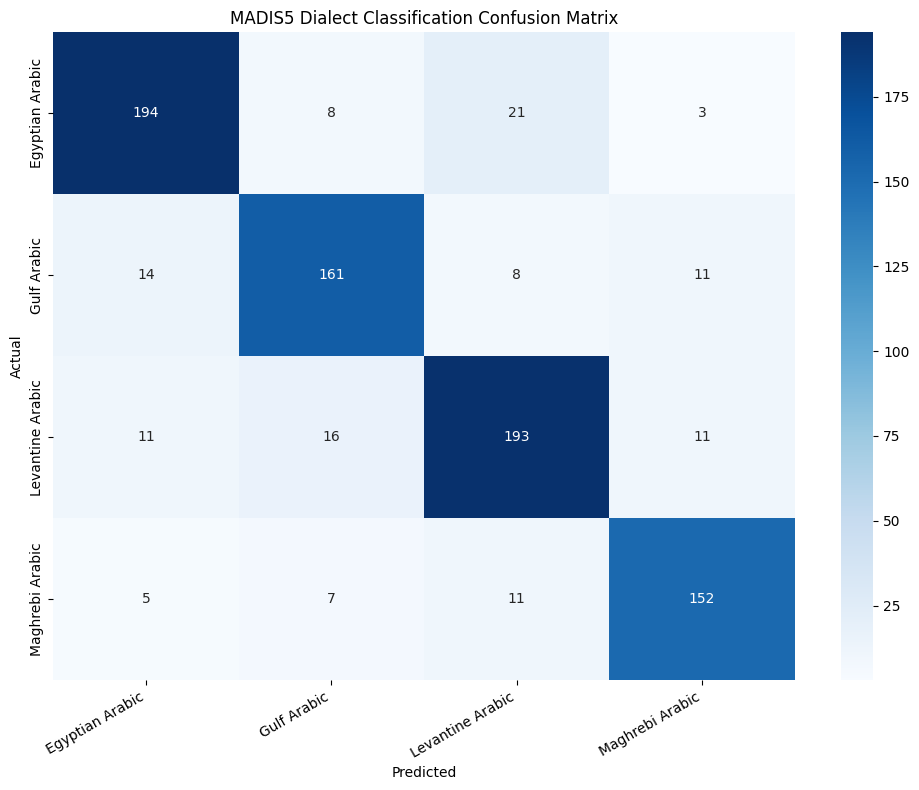

In [ ]:
cm = confusion_matrix(y_test, predictions, labels=DIALECTS)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=DIALECTS,
    yticklabels=DIALECTS
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MADIS5 Dialect Classification Confusion Matrix")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


# 12. Spectrogram Visualization

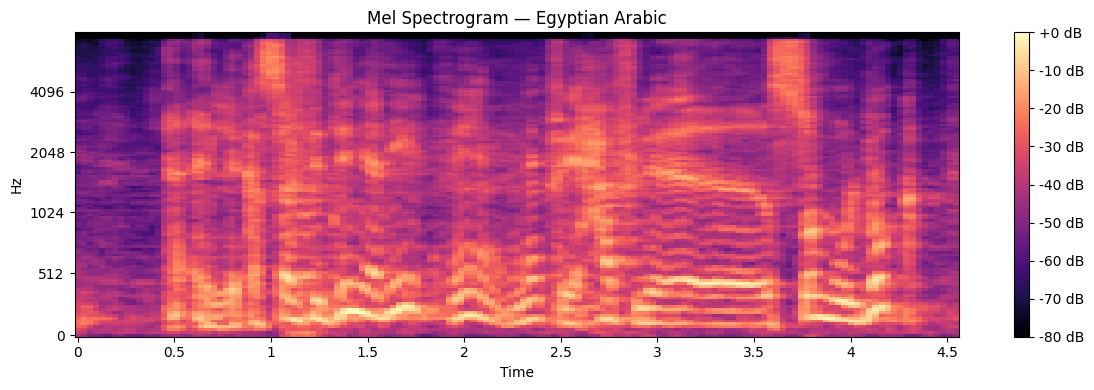

In [ ]:
# Visualize mel spectrogram of a sample from each dialect
ds = load_dataset("badrex/MADIS5-spoken-arabic-dialects")

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

# Get first sample
sample = ds['test'][0]
signal = np.array(sample['audio']['array'], dtype=np.float32)
sr = sample['audio']['sampling_rate']

spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr)
spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel Spectrogram — {sample["dialect"]}')
plt.tight_layout()
plt.show()


 13. Visualizing Distinguishing Features

To show distinguishable differences between dialects, we visualize the MFCC distributions.

In [ ]:
# Load MADIS5 and visualize MFCC distribution per dialect
ds = load_dataset("badrex/MADIS5-spoken-arabic-dialects")

mfcc_data = []
dialect_counts = {d: 0 for d in DIALECTS}

for sample in ds['test']:
    dialect = sample['dialect']
    if dialect not in DIALECTS:
        continue
    if dialect_counts[dialect] >= 20:
        continue
    dialect_counts[dialect] += 1

    signal = np.array(sample['audio']['array'], dtype=np.float32)
    sr = sample['audio']['sampling_rate']

    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)

    mfcc_data.append([dialect, mfcc_mean[0], mfcc_mean[1]])

mfcc_df = pd.DataFrame(mfcc_data, columns=['Dialect', 'MFCC1', 'MFCC2'])


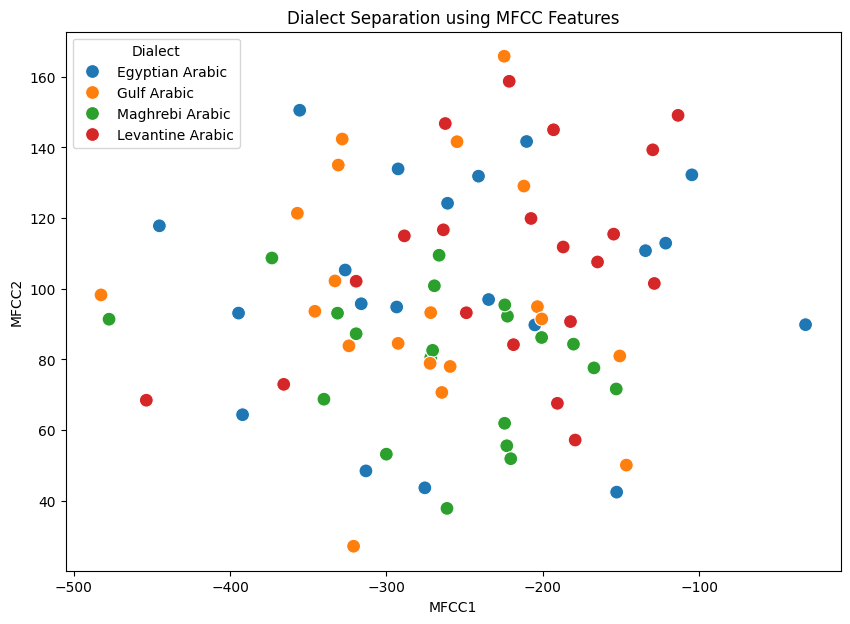

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=mfcc_df,
    x='MFCC1',
    y='MFCC2',
    hue='Dialect',
    s=100
)

plt.title('Dialect Separation using MFCC Features')

plt.show()

# 14. PCA Visualization

Reduce feature dimensions for visualization.

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'Dialect': y
})

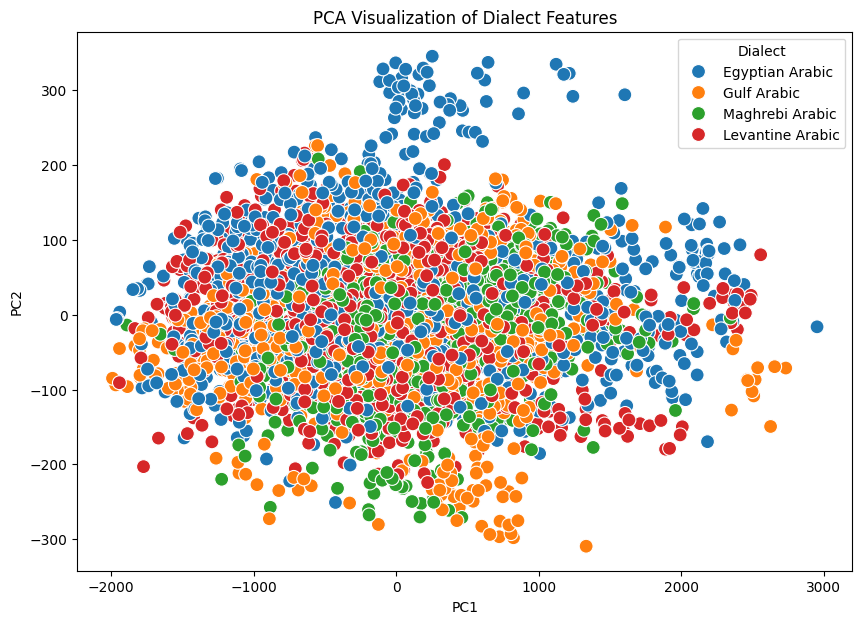

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Dialect',
    s=100
)

plt.title('PCA Visualization of Dialect Features')

plt.show()

# 15. Predict New Audio File

In [ ]:
def predict_dialect(audio_path):
    features = extract_features(audio_path)
    if features is None:
        print('Feature extraction failed.')
        return

    features_scaled = scaler.transform([features])
    probabilities = model.predict_proba(features_scaled)[0]

    # Always pick the class with highest probability
    best_idx   = np.argmax(probabilities)
    prediction = model.classes_[best_idx]

    print(f'Predicted Dialect: {prediction}')
    print()
    for dialect, prob in sorted(zip(model.classes_, probabilities), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f'  {dialect:<12} {prob:.2f}  {bar}')


In [ ]:
# To predict a custom audio file, call:
# predict_dialect("/path/to/your/audio.wav")

# Example using a sample from the dataset:
ds = load_dataset("badrex/MADIS5-spoken-arabic-dialects")
sample = ds['test'][0]
test_audio = np.array(sample['audio']['array'], dtype=np.float32)
test_sr = sample['audio']['sampling_rate']
if test_sr != 22050:
    test_audio = librosa.resample(test_audio, orig_sr=test_sr, target_sr=22050)

features = extract_features_from_signal(test_audio, 22050)
features_scaled = scaler.transform([features])
probabilities = model.predict_proba(features_scaled)[0]
best_idx = np.argmax(probabilities)
prediction = model.classes_[best_idx]

print(f'True Label:       {sample["dialect"]}')
print(f'Predicted Dialect: {prediction}')
print()
for dialect, prob in sorted(zip(model.classes_, probabilities), key=lambda x: -x[1]):
    bar = '█' * int(prob * 30)
    print(f'  {dialect:<25} {prob:.2f}  {bar}')


True Label:       Egyptian Arabic
Predicted Dialect: Egyptian Arabic

  Egyptian Arabic           0.94  ████████████████████████████
  Maghrebi Arabic           0.03  
  Levantine Arabic          0.02  
  Gulf Arabic               0.01  


In [ ]:
predict_dialect("egy.mp3")

Predicted Dialect: Levantine Arabic

  Levantine Arabic 0.54  ████████████████
  Gulf Arabic  0.35  ██████████
  Egyptian Arabic 0.11  ███
  Maghrebi Arabic 0.00  


# 16. Save Trained Model

In [27]:
joblib.dump(model, "dialect_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# 17. Load Model Later


In [ ]:
model = joblib.load("dialect_model.pkl")
scaler = joblib.load("scaler.pkl")

# 18. Weighted Average Between Two Audio Files
This supports Task 5 requirement.

The user can combine two dialects with a weighting slider.

Example:

- 70% Egyptian
- 30% Moroccan

Then classify the mixed signal.

In [ ]:
def mix_audio(file1, file2, weight=0.5):
    """Mix two audio files by path."""
    y1, sr1 = librosa.load(file1, sr=22050)
    y2, sr2 = librosa.load(file2, sr=22050)
    min_len = min(len(y1), len(y2))
    mixed = (weight * y1[:min_len]) + ((1 - weight) * y2[:min_len])
    return mixed, sr1

def mix_audio_arrays(y1, y2, sr, weight=0.5):
    """Mix two audio numpy arrays."""
    min_len = min(len(y1), len(y2))
    y1 = y1[:min_len]
    y2 = y2[:min_len]
    mixed = (weight * y1) + ((1 - weight) * y2)
    return mixed, sr


In [ ]:
# Mix two samples from the MADIS5 dataset
ds = load_dataset("badrex/MADIS5-spoken-arabic-dialects")

# Find one Egyptian and one Gulf sample
samples = {}
for sample in ds['test']:
    d = sample['dialect']
    if d in ['Egyptian Arabic', 'Gulf Arabic'] and d not in samples:
        samples[d] = sample
    if len(samples) == 2:
        break

y1 = np.array(samples['Egyptian Arabic']['audio']['array'], dtype=np.float32)
y2 = np.array(samples['Gulf Arabic']['audio']['array'], dtype=np.float32)
sr1 = samples['Egyptian Arabic']['audio']['sampling_rate']
sr2 = samples['Gulf Arabic']['audio']['sampling_rate']

# Resample both to 22050
if sr1 != 22050:
    y1 = librosa.resample(y1, orig_sr=sr1, target_sr=22050)
if sr2 != 22050:
    y2 = librosa.resample(y2, orig_sr=sr2, target_sr=22050)
sr = 22050

mixed_signal, sr = mix_audio_arrays(y1, y2, sr, weight=0.7)
print(f"Mixed Egyptian Arabic (70%) + Gulf Arabic (30%), length: {len(mixed_signal)/sr:.2f}s")


# 19. Feature Extraction from Signal


In [ ]:
# extract_features_from_signal is already defined in Section 5 above.
# It works on numpy arrays directly — no need to redefine here.
print("extract_features_from_signal is ready.")


# 20. Predict Mixed Audio


In [ ]:
features = extract_features_from_signal(mixed_signal, sr)

features_scaled = scaler.transform([features])

prediction = model.predict(features_scaled)[0]
probabilities = model.predict_proba(features_scaled)[0]

print("Mixed Audio Prediction:", prediction)
print()
for dialect, prob in sorted(zip(model.classes_, probabilities), key=lambda x: -x[1]):
    bar = '█' * int(prob * 30)
    print(f'  {dialect:<25} {prob:.2f}  {bar}')
